# Baseline models

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import xgboost as xgb
import joblib

In [2]:
df = pd.read_csv('../data/clean/full_data.csv')

In [ ]:
df.head()

,casos,week_canton,rr,clasi_rr,urb,tmin_mean,tmax_mean,temp_prom,precip_total,precip_max,...,precip_median_lag_2,precip_median_lag_1,precip_min_lag_8,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1
0,4,2020-9-101,0.459451,Medio,1,18.775265,27.372263,23.073764,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2020-10-101,0.224397,Medio,1,18.723231,27.568323,23.145777,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2020-11-101,0.253939,Medio,1,19.110772,27.610641,23.360707,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,2020-12-101,0.000000,Bajo,1,18.967383,27.361927,23.164655,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,2020-13-101,0.000000,Bajo,1,18.653528,27.606657,23.130092,1.409859,1.409859,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.drop(columns=['casos'], inplace=True)
df.drop(columns=['clasi_rr'], inplace=True)
df.drop(columns = ["tmax_mean"], inplace = True)
df.drop(columns = ["tmin_mean"], inplace = True)
df.drop(columns = ["temp_prom"], inplace = True)
df.drop(columns = ["precip_total"], inplace = True)
df.drop(columns = ["precip_max"], inplace = True)
df.drop(columns = ["precip_min"], inplace = True)
df.drop(columns = ["precip_median"], inplace = True)
df.drop(columns = ["precip_mean"], inplace = True)
df.drop(columns = ["ndvi"], inplace = True)

In [4]:
df.drop(columns = ["clasi_rr_lag_1"], inplace = True)
df.drop(columns = ["casos_lag_1"], inplace = True)
df.drop(columns = ["clasi_rr_lag_2"], inplace = True)
df.drop(columns = ["casos_lag_2"], inplace = True)
df.drop(columns = ["clasi_rr_lag_3"], inplace = True)
df.drop(columns = ["casos_lag_3"], inplace = True)
df.drop(columns = ["clasi_rr_lag_4"], inplace = True)
df.drop(columns = ["casos_lag_4"], inplace = True)
df.drop(columns = ["clasi_rr_lag_5"], inplace = True)
df.drop(columns = ["casos_lag_5"], inplace = True)
df.drop(columns = ["clasi_rr_lag_6"], inplace = True)
df.drop(columns = ["casos_lag_6"], inplace = True)
df.drop(columns = ["clasi_rr_lag_7"], inplace = True)
df.drop(columns = ["casos_lag_7"], inplace = True)
df.drop(columns = ["clasi_rr_lag_8"], inplace = True)
df.drop(columns = ["casos_lag_8"], inplace = True)

In [6]:
df.shape

(24928, 92)

In [7]:
df = pd.get_dummies(df, columns = ["urb"])

In [8]:
df.head()

,week_canton,rr,nino34ssta,rr_lag_8,rr_lag_7,rr_lag_6,rr_lag_5,rr_lag_4,rr_lag_3,rr_lag_2,...,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1,urb_0,urb_1,urb_2
0,2020-9-101,0.459451,0.392222,0.258311,0.930583,1.356304,0.657643,0.000000,0.198219,0.565269,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
1,2020-10-101,0.224397,0.411116,0.930583,1.356304,0.657643,0.000000,0.198219,0.565269,0.295343,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
2,2020-11-101,0.253939,0.453418,1.356304,0.657643,0.000000,0.198219,0.565269,0.295343,0.459451,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
3,2020-12-101,0.000000,0.474281,0.657643,0.000000,0.198219,0.565269,0.295343,0.459451,0.224397,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
4,2020-13-101,0.000000,0.449209,0.000000,0.198219,0.565269,0.295343,0.459451,0.224397,0.253939,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False


In [5]:
train = df[df['week_canton'] < '2024-1-101']
val = df[(df['week_canton'] >= '2024-1-101') & (df['week_canton'] < '2025-1-101')]
test = df[df['week_canton'] >= '2025-1-101']

X_train = train.drop(columns = ["rr", "week_canton"])
y_train = train['rr']

X_val = val.drop(columns = ["rr", "week_canton"])
y_val= val['rr']

X_test= test.drop(columns = ["rr", "week_canton"])
y_test = test['rr']

In [10]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [11]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [12]:
train.shape, val.shape, test.shape

((16400, 94), (4264, 94), (4264, 94))

## Linear regression

In [13]:
reg = LinearRegression().fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

In [14]:
r2_reg = r2_score(y_test_for_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_for_reg, y_pred_reg)
rmse_reg = root_mean_squared_error(y_test_for_reg, y_pred_reg)

In [15]:
print(f"""R2 reg: {round(r2_reg, 3)}
MAE reg: {round(mae_reg, 3)}
RMSE reg: {round(rmse_reg, 3)}
      """)

R2 reg: 0.564
MAE reg: 0.729
RMSE reg: 1.502
      


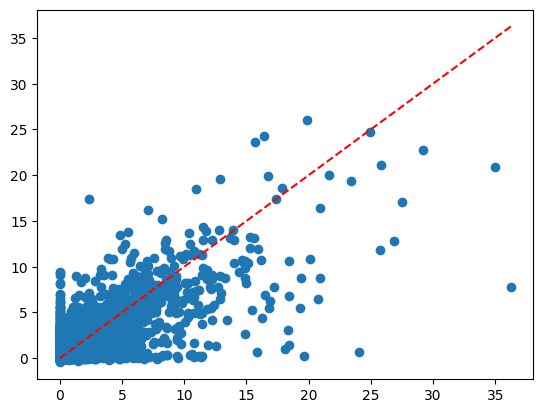

In [16]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_reg)

In [17]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": reg.coef_})
sd = pd.DataFrame({"Feature": X_train.columns, "Std": X_train_scaled.std()})
coef_df = coef_df.merge(sd, on = "Feature")
coef_df["Coefficient_std"] = coef_df["Coefficient"] * coef_df["Std"]
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=False)

coef_reg_sorted

,Feature,Coefficient,Std,Coefficient_std
35,nino34ssta_lag_6,1.391375,1.00003,1.391418
8,rr_lag_1,1.282161,1.00003,1.282200
7,rr_lag_2,0.802080,1.00003,0.802104
40,nino34ssta_lag_1,0.647559,1.00003,0.647579
33,nino34ssta_lag_8,0.628826,1.00003,0.628846
...,...,...,...,...
49,precip_total_lag_8,-0.339434,1.00003,-0.339444
37,nino34ssta_lag_4,-0.440823,1.00003,-0.440837
0,nino34ssta,-0.461597,1.00003,-0.461611
39,nino34ssta_lag_2,-0.466792,1.00003,-0.466806


Text(0.5, 0, 'Coefficient')

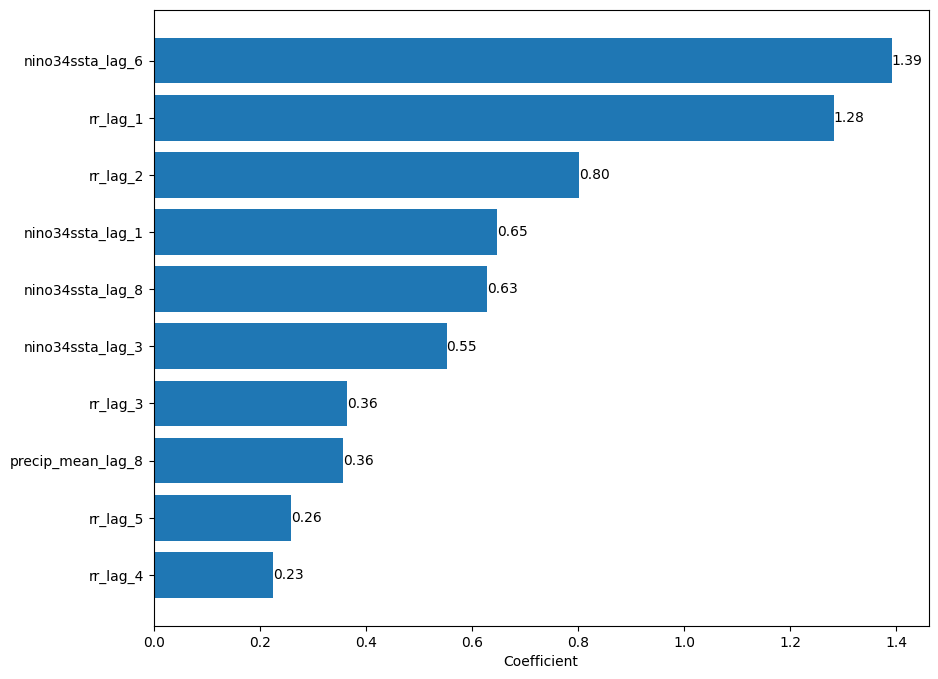

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=True)
ax.barh(coef_reg_sorted["Feature"].tail(10), coef_reg_sorted["Coefficient_std"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Coefficient")

### Random forest

In [ ]:
rf = RandomForestRegressor(oob_score=True)

# 2. Define search space
param_grid_rf = {
    'max_depth': [5, 6, 7, 8],
    'min_samples_split': [10, 100, 500],
    'ccp_alpha': [0, 1 /  10**5, 1 / 10**4, 1 / 10**3, 0.01, 0.1, 1, 10], 
    "criterion": ["squared_error", "absolute_error"]
}

# 3. Initialize and run Grid Search
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv = 5, n_jobs=-1, verbose=10)
grid_rf.fit(X_train, y_train)

In [ ]:
joblib.dump(grid_rf, "../models/rr_rf.pkl")

In [ ]:
y_pred_rf = grid_rf.predict(X_test_for_reg)

In [ ]:
mae_rf = mean_absolute_error(y_test_for_reg, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test_for_reg, y_pred_rf)

In [21]:
print(f"""MAE reg: {round(mae_rf, 3)}
RMSE reg: {round(rmse_rf, 3)}
      """)

MAE reg: 0.801
RMSE reg: 1.572
      


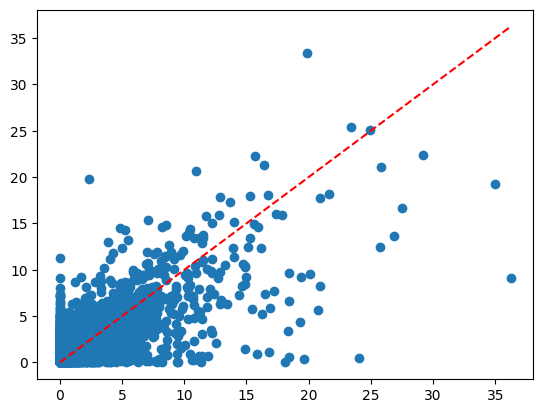

In [22]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_rf)

In [ ]:
imp_rf_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_rf.best_estimator_.feature_importances_})
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=False)

imp_rf_sorted

,Feature,Importance
8,rr_lag_1,0.538746
7,rr_lag_2,0.153773
5,rr_lag_4,0.031686
6,rr_lag_3,0.027834
4,rr_lag_5,0.012720
...,...,...
85,precip_min_lag_4,0.000391
88,precip_min_lag_1,0.000383
89,urb_0,0.000359
83,precip_min_lag_6,0.000329


Text(0.5, 0, 'Importance')

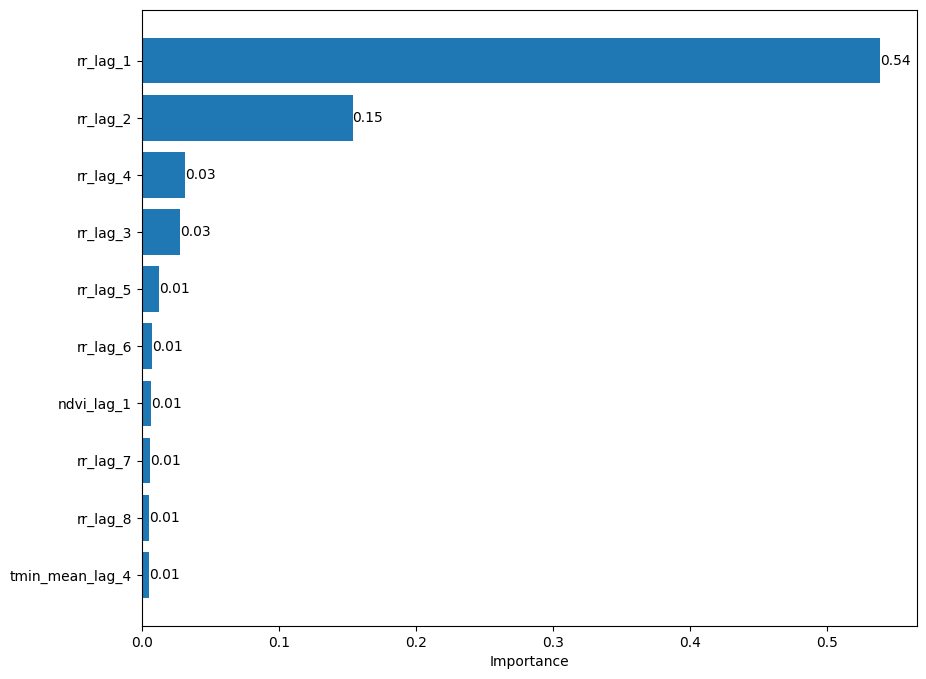

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_rf_sorted["Feature"].tail(10), imp_rf_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

## XGBoost

In [ ]:
xgb = XGBRegressor()

# 2. Define search space
param_grid_xgb = {
    'max_depth': [5, 6, 7, 8],
    'learning_rate': [0.1, 0.3, 0.05],
    'n_estimator': [50, 100, 150], 
    "criterion": ["friednman_mse", "squared_error"]
}

# 3. Initialize and run Grid Search
grid_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, cv = 5, n_jobs=-1, verbose=0)
grid_xgb.fit(X_train, y_train)

In [ ]:
joblib.dump(grid_xgb, "../models/rr_xgb.pkl")

In [ ]:
y_pred_xgb = grid_xgb.predict(X_test_for_reg)

In [ ]:
mae_xgb = mean_absolute_error(y_test_for_reg, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test_for_reg, y_pred_xgb)

In [ ]:
print(f"""MAE xgb: {round(mae_xgb, 3)}
RMSE xgb: {round(rmse_xgb, 3)}
      """)

In [ ]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_xgb)

In [ ]:
imp_xgb_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_xgb.best_estimator_.feature_importances_})
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=False)

imp_xgb_sorted

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_xgb_sorted["Feature"].tail(10), imp_xgb_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

In [25]:
# REMEMBER TO RUN THE CODE WITHOUT URB DUMMIES

In [ ]:
# dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
# dval = xgb.DMatrix(X_val, y_val, enable_categorical=True)
# dtest = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [ ]:
# params = {"objective": "reg:squarederror", "tree_method": "hist"}

In [ ]:
# n = 100
# xgb_model = xgb.train(
#    params=params,
#    dtrain=dtrain,
#    num_boost_round=n,
#    evals=[(dtrain, "train"), (dval, "validation")],
#    verbose_eval=10, 
#    early_stopping_rounds=50
# )

[0]	train-rmse:2.50239	validation-rmse:1.70704
[10]	train-rmse:1.19397	validation-rmse:1.07666
[20]	train-rmse:1.05611	validation-rmse:1.08312
[30]	train-rmse:0.93084	validation-rmse:1.09941
[40]	train-rmse:0.86325	validation-rmse:1.10609
[50]	train-rmse:0.79210	validation-rmse:1.12803
[60]	train-rmse:0.72100	validation-rmse:1.14334
[64]	train-rmse:0.69822	validation-rmse:1.14758


In [ ]:
# xgb_preds = xgb_model.predict(dtest)

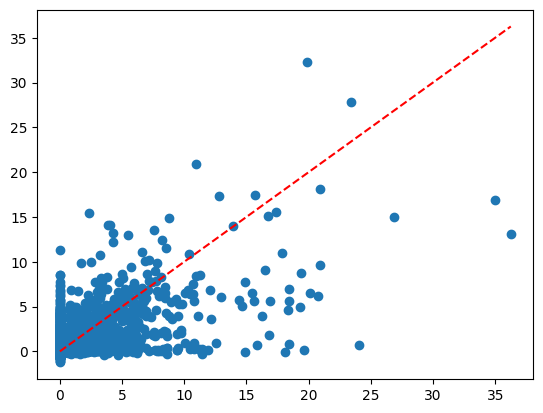

In [ ]:
# fig, ax = plt.subplots()
# ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
# ax.scatter(y_test, xgb_preds)

In [ ]:
# mae_xgb = mean_absolute_error(y_test, xgb_preds)
# rmse_xgb = root_mean_squared_error(y_test, xgb_preds)

# print(f"""MAE xgb: {round(mae_xgb, 3)}
# RMSE xgb: {round(rmse_xgb, 3)}
#       """)

MAE xgb: 0.953
RMSE xgb: 1.968
      


In [ ]:
# importance_xgb = xgb_model.get_score(importance_type="weight")
# importance_xgb_df = pd.DataFrame({"Feature": list(importance_xgb.keys()), "Importance": list(importance_xgb.values())})
# importance_xgb_sorted = importance_xgb_df.sort_values(by = "Importance", ascending=False) 
# importance_xgb_sorted.head(10)

,Feature,Importance
9,rr_lag_1,189.0
1,nino34ssta,163.0
2,rr_lag_8,147.0
8,rr_lag_2,147.0
7,rr_lag_3,123.0
6,rr_lag_4,121.0
3,rr_lag_7,101.0
5,rr_lag_5,99.0
4,rr_lag_6,92.0
0,urb,84.0


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

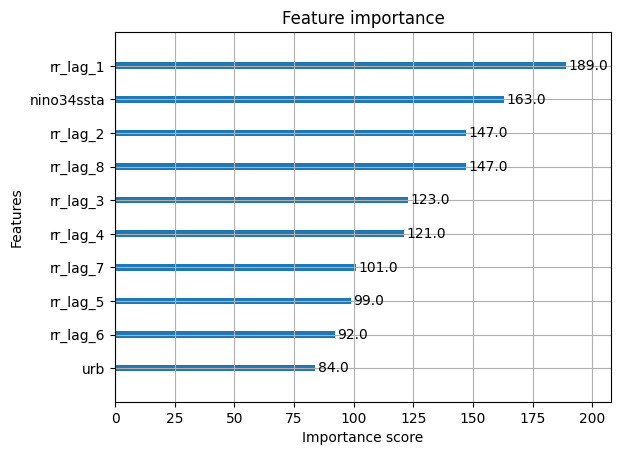

In [ ]:
# xgb.plot_importance(xgb_model, max_num_features=10, importance_type="weight")